import Libraries

In [54]:
import pandas as pd  #Data Analize
import matplotlib.pyplot as plt  #Data Visulise

import numpy as np  #Data Analize
import seaborn as sns  #Data Visualize

from sklearn.model_selection  import train_test_split # to slplit into trainig and testing
from sklearn.linear_model  import LinearRegression #import linear regression model
from sklearn.metrics import accuracy_score, confusion_matrix #evaluation


Data Collection

In [55]:
np.random.seed(42)

study_hours = np.random.uniform(1,10,100)
marks = 10 * study_hours + np.random.normal(0,5,100)

df = pd.DataFrame({
     "StudyHours": study_hours.round(2),
     "Marks": marks.round(2)

})
df

,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


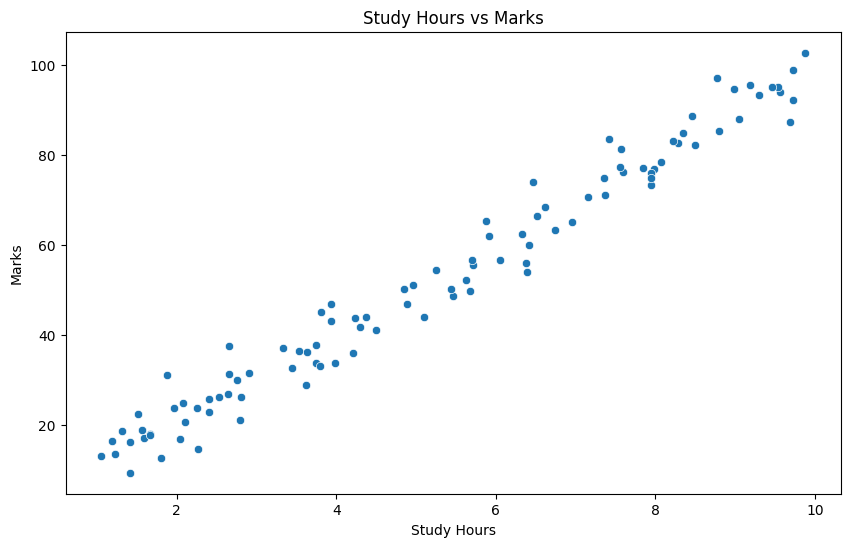

In [56]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="StudyHours",y="Marks")
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()


In [57]:
#print first five rows
df.head()
df.tail()

,StudyHours,Marks
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67
99,1.97,23.85


In [58]:
#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudyHours  100 non-null    float64
 1   Marks       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [59]:
# display statical memory
df.describe()

,StudyHours,Marks
count,100.000000,100.000000
mean,5.232100,52.311100
std,2.677397,26.477629
min,1.050000,9.470000
25%,2.735000,29.730000
50%,5.175000,49.990000
75%,7.575000,76.092500
max,9.880000,102.730000


In [60]:
#check for missing or null values
df.notnull().sum()

,0
StudyHours,100
Marks,100


In [61]:
#check the duplicate values
df.duplicated().sum()

np.int64(0)

In [62]:
#drop the duplicate value
df.drop_duplicates()

,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


In [63]:
#drop the null value
df.dropna()

,StudyHours,Marks
0,4.37,44.14
1,9.56,94.07
2,7.59,76.34
3,6.39,53.94
4,2.40,22.94
...,...,...
95,5.44,50.36
96,5.70,56.66
97,4.85,50.18
98,1.23,13.67


In [64]:
#checks data type
df.dtypes

,0
StudyHours,float64
Marks,float64


In [65]:
# dataset shape
df.shape

(100, 2)

Train Model

In [66]:
# define features and target

#inputs
x=df[["StudyHours"]]

#output Dependent variable
y=df[["Marks"]]

In [67]:
#split data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
#create linear regression object
model = LinearRegression()

#train model
model.fit(x_train,y_train)

LinearRegression()

Test model

In [69]:
y_pred = model.predict(x_test)

Individual value testing

Evaulate Model

In [70]:
from sklearn.metrics import mean_absolute_error,r2_score

In [72]:
# calculate Mean Absolute Error
mae =mean_absolute_error(y_test,y_pred)
mae

2.9480370450598263

In [91]:
from sklearn.metrics import mean_squared_error
#calculate Mean Square Error
mse=mean_squared_error(y_test,y_pred)
mse

16.262700706811483

In [77]:
r2=r2_score(y_test,y_pred)
r2

0.9784699264524137

Plot RegressionLine

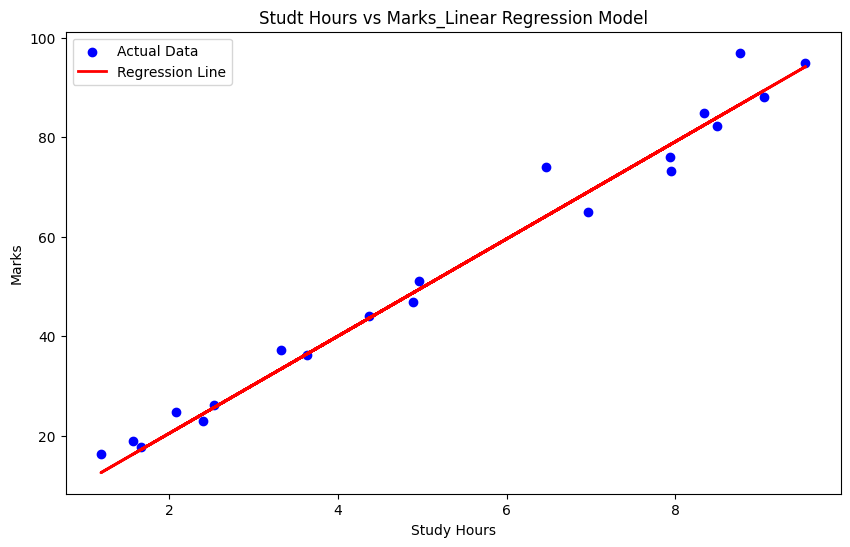

In [78]:
plt.figure(figsize=[10,6])
plt.scatter(x_test,y_test,color="blue",label="Actual Data")
plt.plot(x_test,y_pred,color="red",linewidth=2,label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Studt Hours vs Marks_Linear Regression Model")
plt.legend()
plt.show()

In [79]:
new_hours = [[7.5]]
predicated_marks = model.predict(new_hours)
predicated_marks.round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[74.26]])

In [80]:
#display
print("slope (co-efficient):",model.coef_[0])


slope (co-efficient): [9.77619009]


In [88]:
#display intercept
print("Intercept:",model.intercept_)

Intercept: [0.93620797]


In [89]:
print("\n Regression Equation:")
print(f"Marks = {model.coef_[0][0]:.2f} * StudyHours + {model.intercept_[0]:.2f}")


 Regression Equation:
Marks = 9.78 * StudyHours + 0.94


In [90]:
import joblib

#save the
joblib.dump(model,"linear_Regression_model.pkl")

print("model saves successfully")


model saves successfully
